# Trabajo Practico Nº2 - PDI (Grupo 6)
Integrantes: Añaños Diego, Quinteros Facundo, Lasarte Roberto

# 0. Importaciónes de Librerias a Usar

In [76]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Detección y clasificación de pastillas

### A. Segmentar el área de la cinta transportadora (ROI) en donde se encuentran las pastillas.

In [77]:
def imshow(img, new_fig=True, title=None, color_img=False, blocking=False, colorbar=False, ticks=False):
    if new_fig:
        plt.figure()
    if color_img:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    if not ticks:
        plt.xticks([]), plt.yticks([])
    if colorbar:
        plt.colorbar()
    if new_fig:
        plt.show(block=blocking)

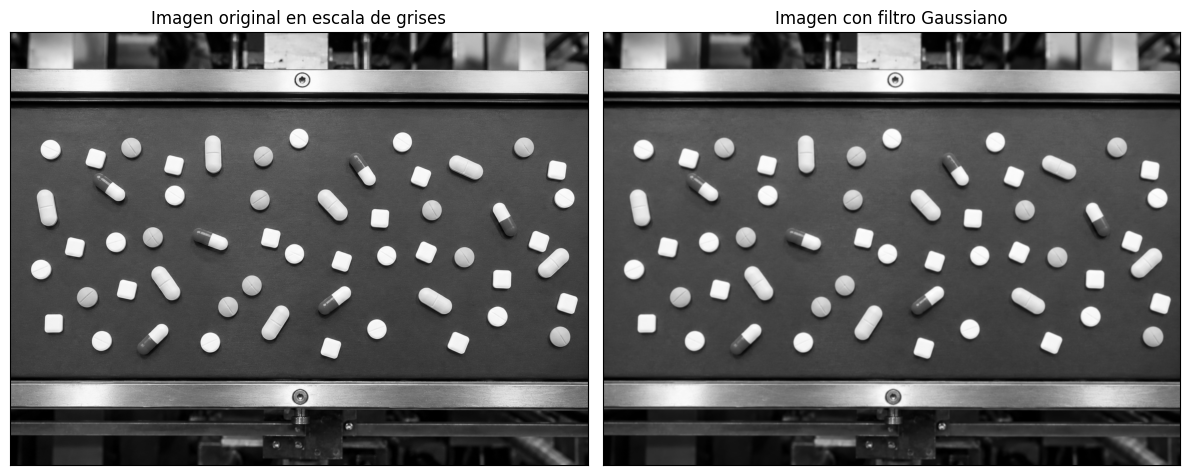

In [78]:
pastillas_gris = cv2.imread('pills.png', cv2.IMREAD_GRAYSCALE)
blur = cv2.GaussianBlur(pastillas_gris, (5,5), 0)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
imshow(pastillas_gris, new_fig=False, title='Imagen original en escala de grises', color_img=False)
plt.subplot(1, 2, 2)
imshow(blur, new_fig=False, title='Imagen con filtro Gaussiano', color_img=False)

plt.tight_layout()
plt.show()

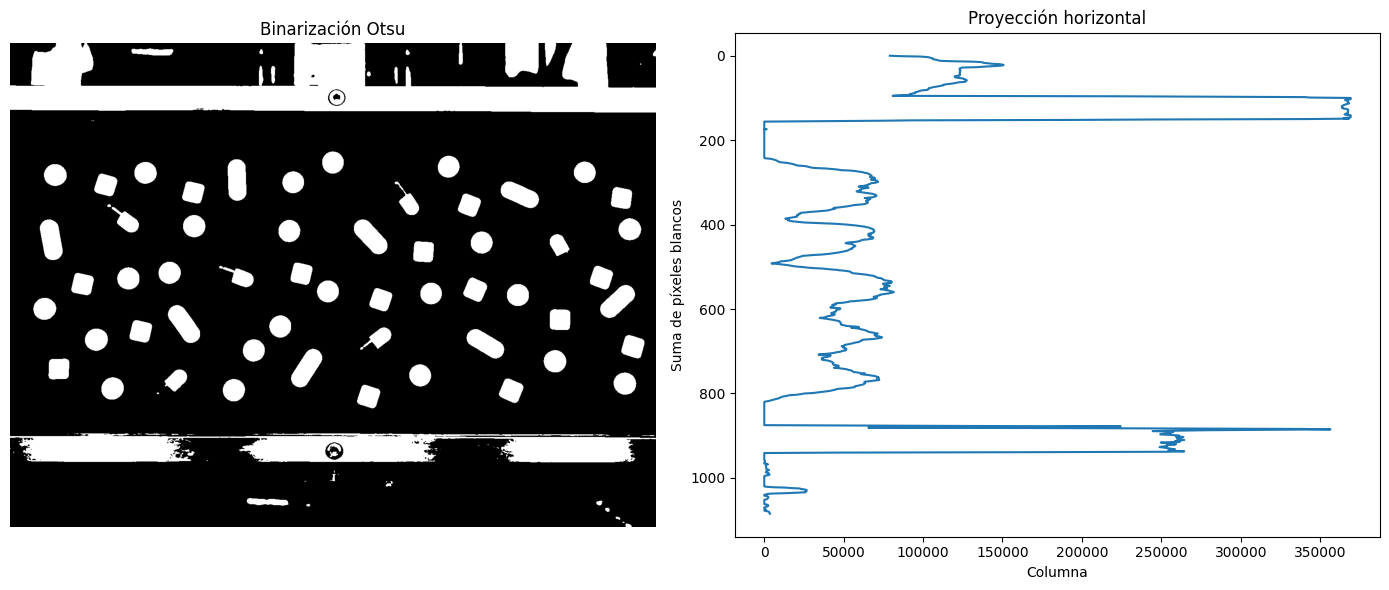

In [79]:
_, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
horizontal_projection = np.sum(mask, axis=1)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap='gray')
plt.title('Binarización Otsu')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.plot(horizontal_projection, np.arange(len(horizontal_projection)))
plt.gca().invert_yaxis()
plt.title('Proyección horizontal')
plt.xlabel('Columna')
plt.ylabel('Suma de píxeles blancos')

plt.tight_layout()
plt.show()

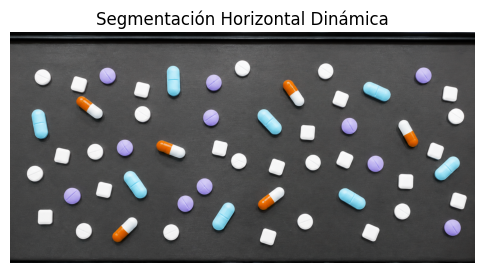

Pico izquierdo en: 100 | Corte superior detectado en: 156
Pico derecho en: 885 | Corte inferior detectado en: 875


In [81]:
# 1. Dividimos el vector a la mitad para aislar el pico izquierdo del derecho
mitad = len(horizontal_projection) // 2

# 2. Encontramos la posición exacta (índice) de los dos picos más altos
pico_izquierdo = np.argmax(horizontal_projection[:mitad])
pico_derecho = np.argmax(horizontal_projection[mitad:]) + mitad

# 3. Definimos un umbral adaptativo basado en la altura de los picos
# Si el pico mide 350.000, el 5% es 17.500. Todo lo que esté abajo es piso/valle.
umbral_corte = 0.05 * horizontal_projection[pico_izquierdo]

# 4. Buscamos el corte superior: avanzamos a la derecha desde el primer pico
# hasta que la señal caiga por debajo del umbral (fin de la barra)
indices_despues_pico1 = np.where(horizontal_projection[pico_izquierdo:] < umbral_corte)[0]
corte_superior = pico_izquierdo + indices_despues_pico1[0]

# 5. Buscamos el corte inferior: retrocedemos a la izquierda desde el segundo pico
# hasta que la señal caiga por debajo del umbral (inicio de la barra)
indices_antes_pico2 = np.where(horizontal_projection[:pico_derecho] < umbral_corte)[0]
corte_inferior = indices_antes_pico2[-1]

# 6. Realizar el recorte final limpio
pastillas = cv2.imread('pills.png')
pastillas_ROI = pastillas[corte_superior:corte_inferior, :]

plt.figure(figsize=(6, 5))
plt.imshow(pastillas_ROI, cmap='gray')
plt.title('Segmentación Horizontal Dinámica')
plt.axis('off')
plt.show()

print(f"Pico izquierdo en: {pico_izquierdo} | Corte superior detectado en: {corte_superior}")
print(f"Pico derecho en: {pico_derecho} | Corte inferior detectado en: {corte_inferior}")

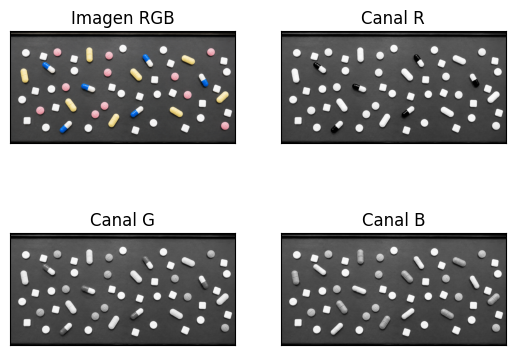

In [83]:
pastillas_ROI_RGB = cv2.cvtColor(pastillas_ROI, cv2.COLOR_BGR2RGB)
B, G, R = cv2.split(pastillas_ROI)    # Separo la imagen en sus respectivos canales.

plt.figure()                                                                        # Analizamos todos los planos juntos.
ax1 = plt.subplot(221); imshow(pastillas_ROI_RGB, title="Imagen RGB", new_fig=False)      
plt.subplot(222,sharex=ax1,sharey=ax1), imshow(R, title="Canal R", new_fig=False)
plt.subplot(223,sharex=ax1,sharey=ax1), imshow(G, title="Canal G", new_fig=False)
plt.subplot(224,sharex=ax1,sharey=ax1), imshow(B, title="Canal B", new_fig=False)
plt.show(block=False)